# NumerAI Rapid Research Template

In [4]:
import sys
import warnings
from pathlib import Path
import os

import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import (
    BayesianRidge,
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
    SGDRegressor,
)

warnings.filterwarnings("ignore")

NOTEBOOK_PATH = Path(
    globals().get("__vsc_ipynb_file__", Path.cwd() / "template.ipynb")
).resolve()
    
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from utils.data import (
    align_on_id,
    apply_validation_embargo,
    build_dataset_columns,
    load_benchmark_frame,
    load_feature_set,
    load_research_data,
    read_parquet_with_id_index,
    resolve_data_dir,
)
from utils.metrics import calculate_metrics
from utils.model_benchmark import compare_top_models_with_current, record_model_metrics
from utils.postprocessing import build_evaluation_frame, neutralize_by_era, rank_by_era
from utils.visualization import display_metrics_table, plot_metric_over_time

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [5]:
DATA_VERSION = "v5.2"
DATA_DIR = "../../data"
TRAIN_PATH = os.path.join(DATA_DIR, DATA_VERSION, "train.parquet")
VALIDATION_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet")
VALIDATION_BENCHMARKS_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet")

FEATURE_SET_KEY = ["small"]
CUSTOM_FEATURE_LIST = None
AUXILIARY_TARGETS = ['target_jasper_20', 'target_teager2b_20', 'target_claudia_20', 'target_rowan_20', 'target_waldo_20', 'target_ender_60', 'target_xerxes_20', 'target_jeremy_20', 'target_cyrusd_20', 'target_agnes_20', 'target_victor_20', 'target_ralph_20']
TARGET_COL = "target_ender_20"
BENCHMARK_COL = "v52_lgbm_ender20"
EMBARGO_ERAS = 4

USE_STANDARD_LOADER = True
ALIGN_VALIDATION_BENCHMARKS = True

ENABLE_NEUTRALIZATION = False
NEUTRALIZATION_PROPORTION = 0.25

FORCE_HISTORY_OVERWRITE = True
RETRAIN_ON_FULL_DATA = False

## 1) Load Data
Use the standard loader for the common case, or switch `USE_STANDARD_LOADER = False` to control paths and columns manually.

In [6]:
_, feature_set = load_feature_set(
    features_path=os.path.join(DATA_DIR, DATA_VERSION, "features.json"),
    feature_set_key=FEATURE_SET_KEY,
    feature_list=CUSTOM_FEATURE_LIST,
)

# Load the label plus all auxiliary targets so auxiliaries can be used as model features.
target_columns = [TARGET_COL] + AUXILIARY_TARGETS

train_columns = build_dataset_columns(
    feature_set=feature_set,
    target_cols=target_columns,
)
validation_columns = build_dataset_columns(
    feature_set=feature_set,
    target_cols=target_columns,
)

train_source = Path(TRAIN_PATH) if TRAIN_PATH is not None else Path(DATA_DIR) / DATA_VERSION / "train.parquet"
validation_source = Path(VALIDATION_PATH) if VALIDATION_PATH is not None else Path(DATA_DIR) / DATA_VERSION / "validation.parquet"
benchmark_source = (
    Path(VALIDATION_BENCHMARKS_PATH)
    if VALIDATION_BENCHMARKS_PATH is not None
    else Path(DATA_DIR) / DATA_VERSION / "validation_benchmark_models.parquet"
)

train = read_parquet_with_id_index(train_source, columns=train_columns)
validation = read_parquet_with_id_index(validation_source, columns=validation_columns)
validation = apply_validation_embargo(
    train=train,
    validation=validation,
    embargo_eras=EMBARGO_ERAS,
)

val_benchmarks = load_benchmark_frame(
    benchmark_path=benchmark_source,
    benchmark_columns=[BENCHMARK_COL],
)

if ALIGN_VALIDATION_BENCHMARKS:
    validation, val_benchmarks = align_on_id(validation, val_benchmarks)

print("Loader mode     :", "standard" if USE_STANDARD_LOADER else "custom")
print("Train shape     :", train.shape)
print("Validation shape:", validation.shape)
print("Feature count   :", len(feature_set))
print("Aux target count:", len(AUXILIARY_TARGETS))
print("Benchmark col   :", BENCHMARK_COL)

print("\nValidation data sample:")
display(validation[["era", TARGET_COL]].head())

Loader mode     : standard
Train shape     : (2746268, 56)
Validation shape: (3921307, 56)
Feature count   : 42
Aux target count: 12
Benchmark col   : v52_lgbm_ender20

Validation data sample:


,era,target_ender_20
id,,
n000c290e4364875,0579,0.50
n002a15bc5575bbb,0579,0.25
n00309caaa0f955e,0579,0.75
n0039cbdcf835708,0579,0.50
n004143458984f89,0579,0.50


In [7]:
print('>> Training era range ', train_era_range := (train["era"].min(), train["era"].max()))
print('>> Validation era range ', val_era_range := (validation["era"].min(), validation["era"].max()))

>> Training era range  ('0001', '0574')
>> Validation era range  ('0579', '1208')


## 2) Train Model

In [8]:
auxiliary_feature_set = [target_name for target_name in AUXILIARY_TARGETS if target_name in train.columns]
if not auxiliary_feature_set:
    raise ValueError("No auxiliary targets were found in loaded data columns.")

train_model_frame = train.dropna(subset=[TARGET_COL]).copy()
validation_model_frame = validation.dropna(subset=[TARGET_COL]).copy()

# Fill missing auxiliary-target features with train medians to keep row count high.
auxiliary_feature_medians = train_model_frame[auxiliary_feature_set].median()
train_model_frame.loc[:, auxiliary_feature_set] = train_model_frame[auxiliary_feature_set].fillna(auxiliary_feature_medians)
validation_model_frame.loc[:, auxiliary_feature_set] = validation_model_frame[auxiliary_feature_set].fillna(auxiliary_feature_medians)


In [9]:

# Candidate models trained on auxiliary-target features only.
ESTIMATORS = {
    "linearreg_aux_features": LinearRegression(),
    "ridge_aux_features": Ridge(alpha=1.0e-6, random_state=42),
    "bayesianridge_aux_features": BayesianRidge(),
    "elasticnet_aux_features": ElasticNet(
        alpha=1.0e-4,
        l1_ratio=0.15,
        max_iter=5000,
        random_state=42,
    ),
    "lasso_aux_features": Lasso(
        alpha=1.0e-5,
        max_iter=5000,
        random_state=42,
    ),
    "sgd_aux_features": SGDRegressor(
        loss="squared_error",
        penalty="elasticnet",
        alpha=1.0e-5,
        l1_ratio=0.15,
        max_iter=4000,
        tol=1.0e-3,
        random_state=42,
    ),
}
MODEL_SELECTION_METRIC = "9_Annualized_Return_PCT"

trained_models = {}
raw_validation_predictions_by_model = {}

for candidate_name, estimator in ESTIMATORS.items():
    candidate_model = clone(estimator)
    candidate_model.fit(
        train_model_frame[auxiliary_feature_set],
        train_model_frame[TARGET_COL],
    )

    candidate_raw_predictions = pd.Series(
        candidate_model.predict(validation_model_frame[auxiliary_feature_set]),
        index=validation_model_frame.index,
        name="prediction",
    )

    trained_models[candidate_name] = candidate_model
    raw_validation_predictions_by_model[candidate_name] = candidate_raw_predictions

    print(candidate_model)
    print(
        f"{candidate_name} raw prediction range:",
        (candidate_raw_predictions.min(), candidate_raw_predictions.max()),
    )

MODEL_NAME = "auxiliary_feature_model_comparison"
print("Train rows used          :", len(train_model_frame))
print("Validation rows used     :", len(validation_model_frame))
print("Auxiliary feature count  :", len(auxiliary_feature_set))
print("Auxiliary feature sample :", auxiliary_feature_set[:6])

LinearRegression()
linearreg_aux_features raw prediction range: (np.float32(-0.0010031164), np.float32(1.0009103))
Ridge(alpha=1e-06, random_state=42)
ridge_aux_features raw prediction range: (np.float32(-0.01771018), np.float32(1.017674))
BayesianRidge()
bayesianridge_aux_features raw prediction range: (np.float32(-0.017709821), np.float32(1.0176736))
ElasticNet(alpha=0.0001, l1_ratio=0.15, max_iter=5000, random_state=42)
elasticnet_aux_features raw prediction range: (np.float32(-0.017331451), np.float32(1.017295))
Lasso(alpha=1e-05, max_iter=5000, random_state=42)
lasso_aux_features raw prediction range: (np.float32(-0.017547518), np.float32(1.0175115))
SGDRegressor(alpha=1e-05, max_iter=4000, penalty='elasticnet', random_state=42)
sgd_aux_features raw prediction range: (np.float64(-0.017337918340774104), np.float64(1.0182398557070775))
Train rows used          : 2746268
Validation rows used     : 3886183
Auxiliary feature count  : 12
Auxiliary feature sample : ['target_jasper_20', '

## 3) Optional Neutralization

In [10]:
print("Neutralization enabled:", ENABLE_NEUTRALIZATION)

final_validation_predictions_by_model = {}
for candidate_name, candidate_raw_predictions in raw_validation_predictions_by_model.items():
    if ENABLE_NEUTRALIZATION:
        candidate_final_predictions = neutralize_by_era(
            predictions=candidate_raw_predictions,
            eras=validation_model_frame["era"],
            features=validation_model_frame[feature_set],
            proportion=NEUTRALIZATION_PROPORTION,
            rank_output=True,
        )
    else:
        candidate_final_predictions = rank_by_era(
            predictions=candidate_raw_predictions,
            eras=validation_model_frame["era"],
            index=validation_model_frame.index,
        )

    final_validation_predictions_by_model[candidate_name] = candidate_final_predictions
    print(
        f"{candidate_name} final prediction range:",
        (candidate_final_predictions.min(), candidate_final_predictions.max()),
    )

Neutralization enabled: False
linearreg_aux_features final prediction range: (np.float64(0.00013681762210972773), np.float64(1.0))
ridge_aux_features final prediction range: (np.float64(0.00013681762210972773), np.float64(1.0))
bayesianridge_aux_features final prediction range: (np.float64(0.00013681762210972773), np.float64(1.0))
elasticnet_aux_features final prediction range: (np.float64(0.00013681762210972773), np.float64(1.0))
lasso_aux_features final prediction range: (np.float64(0.00013681762210972773), np.float64(1.0))
sgd_aux_features final prediction range: (np.float64(0.00013681762210972773), np.float64(1.0))


## 4) Evaluate

In [11]:
evaluation_frames_by_model = {}
for candidate_name, candidate_predictions in final_validation_predictions_by_model.items():
    evaluation_frames_by_model[candidate_name] = build_evaluation_frame(
        validation=validation_model_frame,
        predictions=candidate_predictions,
        target_col=TARGET_COL,
    )

print("Prepared evaluation frames:", len(evaluation_frames_by_model))

Prepared evaluation frames: 6


In [12]:
metrics_by_model = {}
per_era_by_model = {}
model_comparison_rows = []

for candidate_name, candidate_evaluation_frame in evaluation_frames_by_model.items():
    candidate_metrics, candidate_per_era_df = calculate_metrics(
        df_validation=candidate_evaluation_frame,
        benchmarks=val_benchmarks,
        features=feature_set,
        target_col=TARGET_COL,
        benchmark_col=BENCHMARK_COL,
        fast_metrics=True,
    )

    metrics_by_model[candidate_name] = candidate_metrics
    per_era_by_model[candidate_name] = candidate_per_era_df

    model_comparison_rows.append(
        {
            "model_name": candidate_name,
            "9_Annualized_Return_PCT": float(candidate_metrics["9_Annualized_Return_PCT"]),
            "1_RAPS": float(candidate_metrics["1_RAPS"]),
            "4_Mean_BMC20": float(candidate_metrics["4_Mean_BMC20"]),
            "3_Mean_CORR20V2": float(candidate_metrics["3_Mean_CORR20V2"]),
            "7_Max_Drawdown_CORR": float(candidate_metrics["7_Max_Drawdown_CORR"]),
            "10_Benchmark_Corr": float(candidate_metrics["10_Benchmark_Corr"]),
            "8_Win_Rate": float(candidate_metrics["8_Win_Rate"]),
        }
    )

model_comparison_df = pd.DataFrame(model_comparison_rows).sort_values(
    by=[MODEL_SELECTION_METRIC, "1_RAPS"],
    ascending=[False, False],
).reset_index(drop=True)

if model_comparison_df.empty:
    raise ValueError("No model metrics were computed.")

best_model_name = model_comparison_df.iloc[0]["model_name"]
MODEL_NAME = best_model_name
model = trained_models[best_model_name]
ESTIMATOR = clone(ESTIMATORS[best_model_name])
metrics = metrics_by_model[best_model_name]
per_era_df = per_era_by_model[best_model_name]
evaluation_frame = evaluation_frames_by_model[best_model_name]
final_validation_predictions = final_validation_predictions_by_model[best_model_name]

print("Selected model:", MODEL_NAME)
print(
    f"Selection metric ({MODEL_SELECTION_METRIC}):",
    model_comparison_df.iloc[0][MODEL_SELECTION_METRIC],
)
print("\nModel comparison table:")
display(model_comparison_df)

Selected model: sgd_aux_features
Selection metric (9_Annualized_Return_PCT): 1164.2808263793454

Model comparison table:


,model_name,9_Annualized_Return_PCT,1_RAPS,4_Mean_BMC20,3_Mean_CORR20V2,7_Max_Drawdown_CORR,10_Benchmark_Corr,8_Win_Rate
0,sgd_aux_features,1164.280826,210.391999,0.787309,0.866521,-0.0,0.036729,1.0
1,ridge_aux_features,1164.280826,210.255642,0.787319,0.866532,-0.0,0.036757,1.0
2,bayesianridge_aux_features,1164.280826,210.255164,0.787319,0.866532,-0.0,0.036757,1.0
3,lasso_aux_features,1164.280826,210.254057,0.787319,0.866532,-0.0,0.036755,1.0
4,elasticnet_aux_features,1164.280826,210.191050,0.787319,0.866520,-0.0,0.036764,1.0
5,linearreg_aux_features,1164.280826,129.129899,0.767932,0.839258,-0.0,0.039906,1.0


# Theoretical Best 
Need to match these metrics 

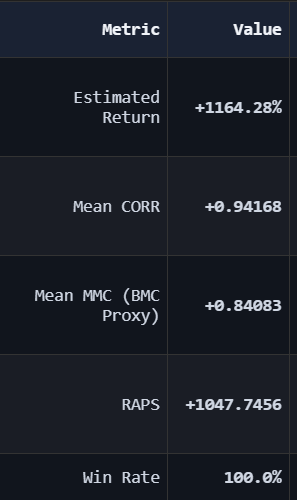

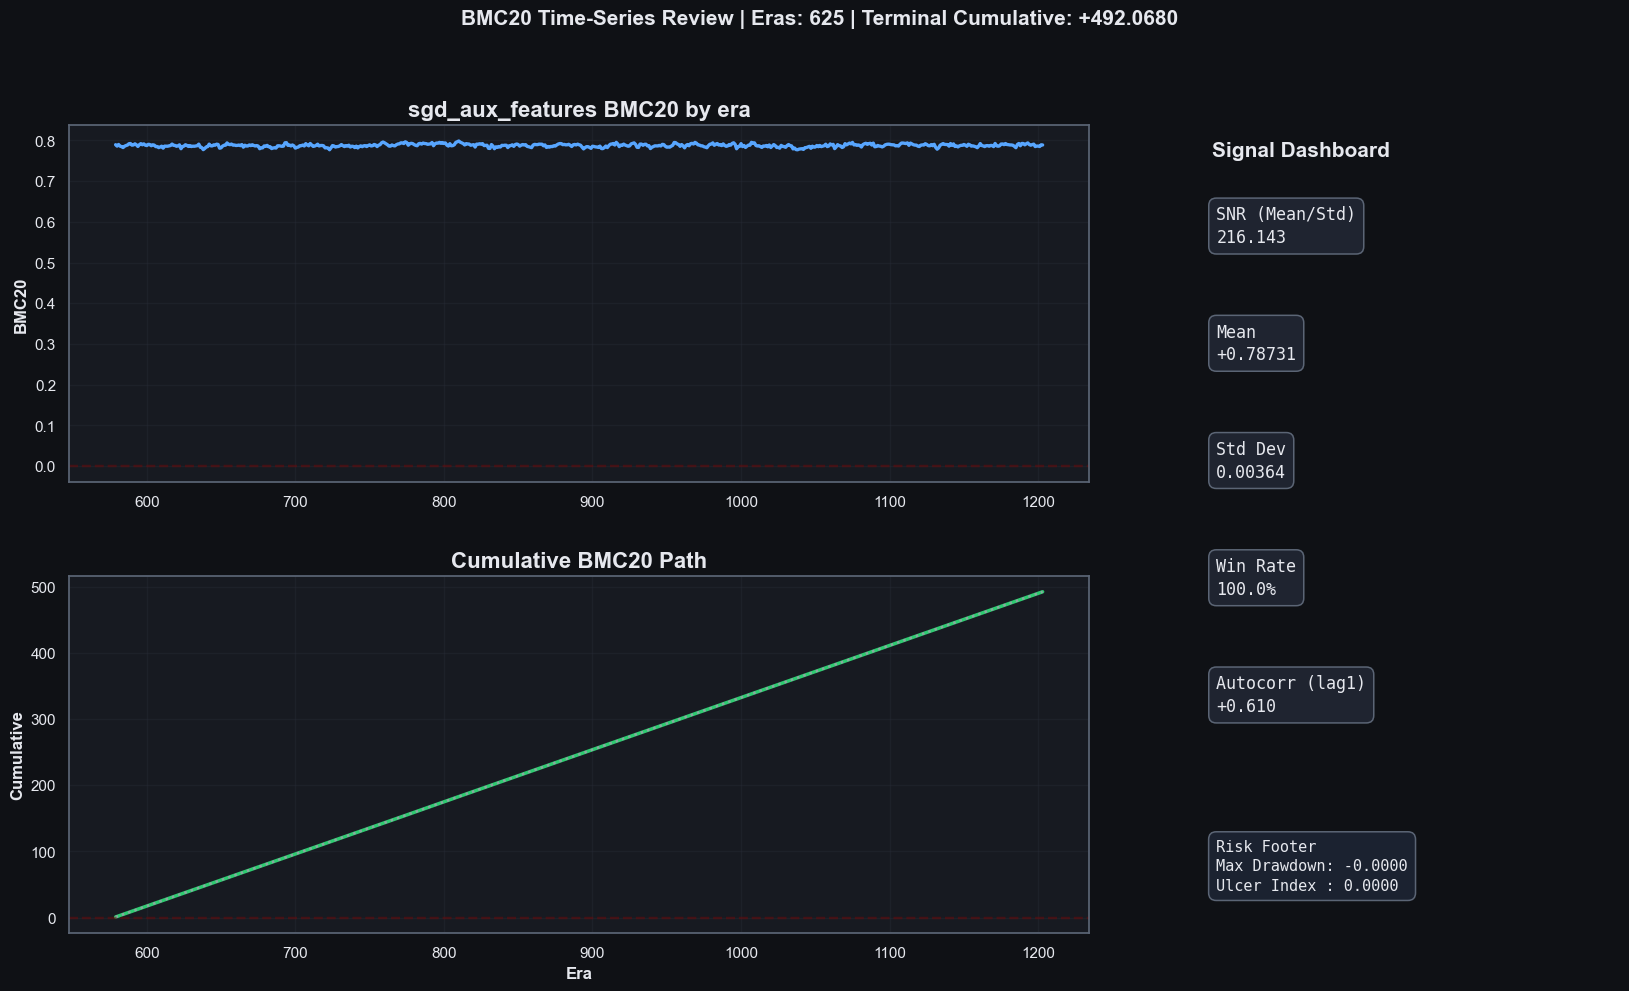

In [13]:
plot_metric_over_time(
        per_era_df=per_era_df,
        metric="BMC20",
        title=f"{MODEL_NAME} BMC20 by era",
    )

In [14]:
assert False

AssertionError: 

In [ ]:
# history_df, record = record_model_metrics(
#     metrics=metrics,
#     model_name=MODEL_NAME,
#     notebook_name=NOTEBOOK_PATH.name,
#     force=FORCE_HISTORY_OVERWRITE,
# )
# display(pd.DataFrame([record]))

In [ ]:
# leaderboard, is_top_model = compare_top_models_with_current(
#     current_run_id=record["run_id"],
#     top_n=5,
#     show_message=True,
# )

## 5) Breakpoint

In [ ]:
assert False, "Inspect metrics and per-era results before retraining on full data."

## 6) Optional Retrain On Full Data

In [ ]:
if not RETRAIN_ON_FULL_DATA:
    print("Set RETRAIN_ON_FULL_DATA = True after removing or bypassing the breakpoint.")
else:
    full_training_frame = pd.concat([train, validation], axis=0)
    full_training_frame = full_training_frame.dropna(subset=[TARGET_COL]).copy()

    final_model = clone(ESTIMATOR)
    final_model.fit(full_training_frame[feature_set], full_training_frame[TARGET_COL])

    print(final_model)
    print("Full-data rows used:", len(full_training_frame))